# Uncertainty-Based Multi-Task Loss Weighting for Diabetic Retinopathy (UWF)

**Method:** Kendall, Gal & Cipolla, *Multi-Task Learning Using Uncertainty to Weigh Losses* (CVPR 2018).

Instead of the hand-picked weights used in the folder-3 baseline
(`loss = asym_lesion + CE_grade + 0.5*supcon_early + 0.5*supcon_deep`), we **learn** a per-task
log-variance `s_i = log(sigma_i^2)` and combine losses as

$$ L_{total} = \sum_i \Big[\, 0.5\,e^{-s_i}\,L_i \; + \; 0.5\,s_i \,\Big] $$

`e^{-s_i}` is the learned task weight; `0.5 s_i` is a regulariser that stops any task's weight collapsing
to zero. This notebook reuses the folder-3 pipeline verbatim and changes **only** the loss combination.

Runs top-to-bottom unattended. Real training is gated behind `CFG['RUN_TRAINING']` (default `False`);
the uncertainty-loss **unit test** and a **forward/backward smoke test** always run.


## 1. Environment Setup
Detect GPUs, print versions. Works on CPU, single GPU, or dual T4 (Kaggle). No new dependencies beyond
the standard `kaggle/python` image (torch, torchvision, sklearn, opencv, pandas, matplotlib, tqdm).

In [21]:
import sys, platform, torch
print("Python :", sys.version.split()[0], "|", platform.system())
print("PyTorch:", torch.__version__)
print("CUDA   :", torch.cuda.is_available(), "| device count:", torch.cuda.device_count())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Python : 3.12.13 | Linux
PyTorch: 2.10.0+cu128
CUDA   : True | device count: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4
Using device: cuda


## 2. Configuration (central config + seed fixing)
One dictionary controls everything. Key flags:
- `RUN_TRAINING` — gate the long loop. Keep `False` for an unattended top-to-bottom pass (unit + smoke
  tests still run); set `True` on a real GPU session.
- `UNCERTAINTY_ON_SUPCON` — `False` (primary): learn weights for **grade + lesion** only, keep SupCon
  fixed at 0.5. `True` (ablation): learn weights for **all four** tasks.
- `INIT_LOG_VAR` — initial `s_i` (0.0 → sigma^2=1 → starting weight 0.5, neutral).
- `BACKUP_TO_DATASET` / `BACKUP_DATASET_SLUG` / `BACKUP_EVERY` — periodically version the checkpoint into a
  Kaggle **Dataset** during training. `/kaggle/working` is wiped when an interactive session idles out; a
  dataset persists, so this is how a checkpoint actually survives to the next session.
- `RESUME` — load the newest checkpoint found under `/kaggle/input` (or local) before training.
Seed fixing makes the run and the train/test split reproducible.

In [30]:
import random, os
import numpy as np
import torch

CFG = {
    # data / modality
    'MODALITY': 'UWF',
    'IMG_SIZE': 512,
    'BATCH_SIZE': 8,            # raise to 16 on dual-T4
    'NUM_WORKERS': 2,
    'SEED': 42,
    # optimisation
    'EPOCHS': 60,
    'LR': 1e-4,                 # network
    'LR_LOGVAR': 1e-3,          # log-variances (own param group)
    'WEIGHT_DECAY': 1e-4,       # network
    'WD_LOGVAR': 0.0,           # log-variances: MUST be 0 (see notes)
    'GRAD_CLIP': 2.0,
    'PATIENCE': 10,
    # uncertainty weighting
    'INIT_LOG_VAR': 0.0,
    'UNCERTAINTY_ON_SUPCON': True,   # primary=False; ablation=True
    'S_CLAMP': 3.0,                   # clamp |s| <= this for numerical safety
    'SUPCON_FIXED_W': 0.5,            # used only when UNCERTAINTY_ON_SUPCON is False
    # loss hyperparams (unchanged from folder 3)
    'FOCAL_GAMMA': 2.0,
    'SUPCON_TEMP': 0.1,
    # control
    'RUN_TRAINING': True,      # <-- flip to True for a real GPU run
    'OUT_DIR': '/kaggle/working' if os.path.isdir('/kaggle/working') else '.',
    # checkpoint backup to a Kaggle Dataset (survives idle-session restarts; /kaggle/working does NOT)
    'BACKUP_TO_DATASET': True,                         # <-- True on a real run to auto-version checkpoints
    'BACKUP_DATASET_SLUG': 'krrish1008/checkpoint',    # your Kaggle dataset id "user/slug"
    'BACKUP_EVERY': 2,                                 # push every N epochs (also always pushes on a new best)
    'RESUME': True,                                    # <-- True to resume from a checkpoint before training
}

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = True   # speed; determinism not required here
set_seed(CFG['SEED'])
os.makedirs(CFG['OUT_DIR'], exist_ok=True)
print("Config ready. RUN_TRAINING =", CFG['RUN_TRAINING'],
      "| UNCERTAINTY_ON_SUPCON =", CFG['UNCERTAINTY_ON_SUPCON'])
print("Output dir:", CFG['OUT_DIR'])

Config ready. RUN_TRAINING = True | UNCERTAINTY_ON_SUPCON = True
Output dir: /kaggle/working


## 3. Imports
All imports in one place (folder-3 stack + AMP + csv/glob for logging and dataset autodetect).

In [31]:
import os, cv2, ast, glob, csv, time, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from PIL import Image
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, cohen_kappa_score, f1_score, roc_auc_score,
                             average_precision_score, balanced_accuracy_score, recall_score,
                             confusion_matrix)
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# AMP (new torch.amp API with graceful fallback)
try:
    from torch.amp import autocast, GradScaler
    AMP_NEW = True
except Exception:
    from torch.cuda.amp import autocast, GradScaler
    AMP_NEW = False
print("Imports OK. New AMP API:", AMP_NEW)

Imports OK. New AMP API: True


## 4. Dataset Validation
**Glob-based autodetect** (robust to the known Kaggle slug discrepancy `mmrdr-dataset` vs
`my-mmrdr-dataset`): search `/kaggle/input` for `UWF.csv`; fall back to the local `../MMRDR` tree. If no
data is found the notebook keeps going (df=None) so it still runs unattended — training is gated anyway.

In [32]:
def find_uwf_csv():
    # 1) Kaggle: glob for UWF.csv anywhere under /kaggle/input
    hits = glob.glob('/kaggle/input/**/UWF.csv', recursive=True)
    if hits:
        return hits[0]
    # 2) local fallbacks relative to repo layout
    for cand in ['../MMRDR/MMRDR-UWF/UWF.csv',
                 '../../MMRDR/MMRDR-UWF/UWF.csv',
                 'MMRDR/MMRDR-UWF/UWF.csv']:
        if os.path.exists(cand):
            return os.path.abspath(cand)
    return None

CSV_PATH = find_uwf_csv()
if CSV_PATH:
    IMG_DIR = os.path.dirname(CSV_PATH)          # UWF.csv 'image' col already includes 'img/...'
    print("Found UWF.csv at:", CSV_PATH)
    print("Image base dir   :", IMG_DIR)
    df = pd.read_csv(CSV_PATH)
    expected = {'type', 'image', 'grade', 'lesion', 'lr'}
    print("Columns:", list(df.columns), "| schema OK:", expected.issubset(set(df.columns)))
    print("Rows:", len(df))
else:
    IMG_DIR, df = None, None
    print("[!] UWF.csv not found. Notebook will still run (dataset cells are guarded).")

Found UWF.csv at: /kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF/UWF.csv
Image base dir   : /kaggle/input/datasets/krrish1008/mmrdr-dataset/MMRDR/MMRDR-UWF
Columns: ['type', 'image', 'grade', 'lesion', 'lr'] | schema OK: True
Rows: 10404


## 5. Dataset Statistics
Class balance drives everything here. Grade is imbalanced; lesions are heavily imbalanced (rare PDR
lesions NV/VH/RD). Lesion index order is fixed: `[0:MA, 1:HE, 2:IH, 3:VB/IRMA, 4:NV, 5:VH, 6:RD]`.

In [33]:
LESION_NAMES = ['MA', 'HE', 'IH', 'VB/IRMA', 'NV', 'VH', 'RD']
RARE_IDX = [4, 5, 6]   # NV, VH, RD -> define Proliferative DR

def parse_lesion(s):
    s = str(s).strip().strip('[]')
    v = np.array([float(x.strip()) for x in s.split(',') if x.strip()], dtype=np.float32)
    if len(v) != 7:
        v = np.zeros(7, dtype=np.float32)
    return (v > 0).astype(np.float32)

if df is not None:
    grade_counts = df['grade'].value_counts().sort_index()
    print("Grade counts (0..4):")
    print(grade_counts.to_string())
    L = np.stack(df['lesion'].apply(parse_lesion).values)
    print("\nLesion positives:")
    for i, n in enumerate(LESION_NAMES):
        print(f"  {n:8s}: {int(L[:, i].sum())}")
    print("Images with >=1 rare lesion:", int((L[:, RARE_IDX].sum(1) > 0).sum()))
else:
    print("Reference UWF stats (from SHARED_CONTEXT): n=10404 | grade {0:3372,1:1936,2:2166,3:1377,4:1553}")
    print("lesion positives {MA:6938,HE:3846,IH:3849,VB:1010,NV:1188,VH:1219,RD:238}")

Grade counts (0..4):
grade
0    3372
1    1936
2    2166
3    1377
4    1553

Lesion positives:
  MA      : 6938
  HE      : 3846
  IH      : 3848
  VB/IRMA : 1010
  NV      : 1188
  VH      : 1219
  RD      : 238
Images with >=1 rare lesion: 1555


## 6. Exploratory Data Analysis
Bar charts of grade and lesion prevalence — visualises *why* task balancing matters: a naive sum-of-
losses lets the common grade classes and common lesions dominate the rare, clinically-critical ones.

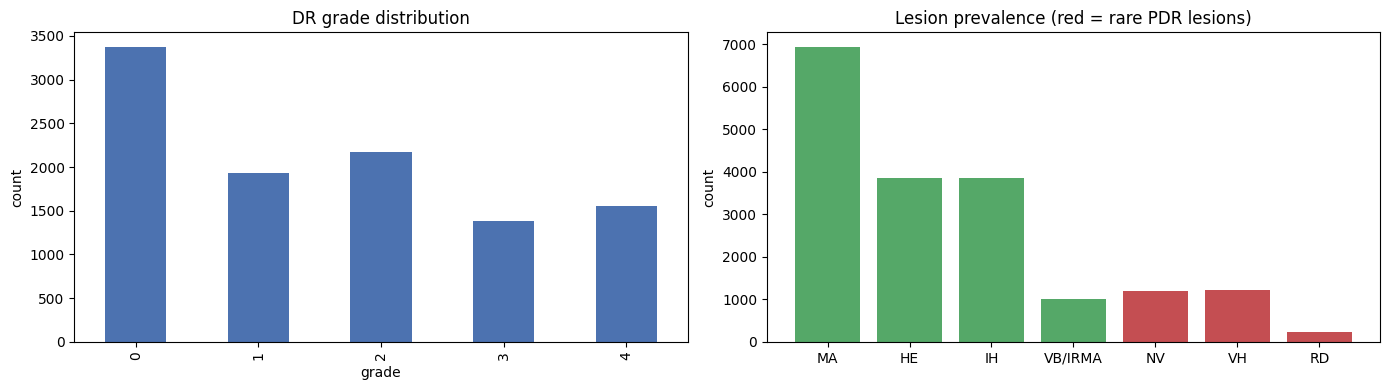

In [34]:
if df is not None:
    fig, ax = plt.subplots(1, 2, figsize=(14, 4))
    df['grade'].value_counts().sort_index().plot(kind='bar', ax=ax[0], color='#4C72B0')
    ax[0].set_title('DR grade distribution'); ax[0].set_xlabel('grade'); ax[0].set_ylabel('count')
    pos = [int(L[:, i].sum()) for i in range(7)]
    bars = ax[1].bar(LESION_NAMES, pos, color=['#55A868']*4 + ['#C44E52']*3)
    ax[1].set_title('Lesion prevalence (red = rare PDR lesions)'); ax[1].set_ylabel('count')
    plt.tight_layout(); plt.show()
else:
    print("EDA skipped (no dataframe). Plots require the dataset.")

## 7. Data Augmentation & Preprocessing
Reused verbatim from folder 3: UWF elliptical masking (`apply_uwf_mask`) to strip eyelid/eyelash
artifacts (resize to 512 **before** cv2 masking so CPU doesn't bottleneck), ImageNet normalisation, and
the folder-3 train augmentations. Val = resize + normalise only.

In [35]:
def apply_uwf_mask(pil_img, tightness=0.98):
    img = np.array(pil_img)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray, 15, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return pil_img
    c = max(contours, key=cv2.contourArea)
    if len(c) >= 5:
        e = cv2.fitEllipse(c)
        e2 = (e[0], (e[1][0]*tightness, e[1][1]*tightness), e[2])
        mask = np.zeros_like(gray); cv2.ellipse(mask, e2, 255, -1)
        return Image.fromarray(cv2.bitwise_and(img, img, mask=mask))
    return pil_img

MEAN = [0.485, 0.456, 0.406]; STD = [0.229, 0.224, 0.225]
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
val_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(MEAN, STD)])

class UWF_Dataset(Dataset):
    def __init__(self, frame, img_dir, transform=None):
        # Pre-extract columns into numpy arrays instead of keeping the DataFrame and calling
        # df.iloc[idx] per item. Under num_workers>0, per-row pandas access bumps Python object
        # refcounts on copy-on-write pages, so each forked worker's RAM creeps up over epochs
        # (the "DataLoader memory leak"). Numeric numpy arrays are not per-element refcounted, so
        # they don't bloat the workers. See PyTorch issue #13246.
        self.img_dir = img_dir
        self.transform = transform
        self.paths = frame['image'].to_numpy()                                      # str paths
        self.grades = frame['grade'].to_numpy().astype(np.int64)                    # [N]
        self.lesions = np.stack(frame['lesion'].apply(parse_lesion).values).astype(np.float32)  # [N,7]
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        p = os.path.join(self.img_dir, self.paths[idx])
        if not os.path.exists(p):
            image = Image.new('RGB', (512, 512), (0, 0, 0))
        else:
            image = Image.open(p).convert('RGB').resize((512, 512), Image.Resampling.BILINEAR)
        image = apply_uwf_mask(image)
        if self.transform:
            image = self.transform(image)
        les = self.lesions[idx]
        has_rare = 1.0 if les[4:].sum() > 0 else 0.0   # SupCon target
        return image, int(self.grades[idx]), torch.from_numpy(les.copy()), torch.tensor(has_rare, dtype=torch.float32)

# Build loaders only if data is present
train_loader = val_loader = None
if df is not None:
    train_df, val_df = train_test_split(df, test_size=0.2, random_state=CFG['SEED'])
    # persistent_workers=False so workers are recreated each epoch -> any per-epoch worker RAM
    # growth is released between epochs instead of accumulating until the 30 GB kernel cap.
    common = dict(num_workers=CFG['NUM_WORKERS'], pin_memory=True)
    train_loader = DataLoader(UWF_Dataset(train_df, IMG_DIR, train_transform),
                              batch_size=CFG['BATCH_SIZE'], shuffle=True, drop_last=True, **common)
    val_loader = DataLoader(UWF_Dataset(val_df, IMG_DIR, val_transform),
                            batch_size=CFG['BATCH_SIZE'], shuffle=False, **common)
    print(f"Loaders ready. Train={len(train_df)}  Val={len(val_df)}")
else:
    print("Loaders skipped (no dataset).")

Loaders ready. Train=8323  Val=2081


## 8. Model Architecture — `UWF_SupConDRNet` (with the log-variance params living in the loss)
The backbone is folder-3's `UWF_SupConDRNet` **unchanged** (ResNet-50 + FPN + two SupCon heads →
`out_lesions, out_grade, z_early, z_deep`). The learnable **log-variance parameters are NOT inside the
model** — they live in the separate `UncertaintyWeightedLoss` module (next section) so they stay on a
single device and are never duplicated by `nn.DataParallel`.

In [36]:
class UWF_SupConDRNet(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1, self.layer2 = resnet.layer1, resnet.layer2   # layer2 -> 512d (early)
        self.layer3, self.layer4 = resnet.layer3, resnet.layer4   # layer4 -> 2048d (deep)
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.proj_early = nn.Sequential(nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, 128))
        self.proj_deep  = nn.Sequential(nn.Linear(2048, 512), nn.ReLU(), nn.Linear(512, 128))
        self.lat_l4 = nn.Conv2d(2048, 512, 1); self.lat_l3 = nn.Conv2d(1024, 512, 1)
        self.lat_l2 = nn.Conv2d(512, 512, 1);  self.lat_l1 = nn.Conv2d(256, 512, 1)
        self.classifier_lesions = nn.Linear(512, 7)
        self.classifier_grade = nn.Linear(512, 5)
    def forward(self, x):
        x = self.stem(x)
        l1 = self.layer1(x); l2 = self.layer2(l1); l3 = self.layer3(l2); l4 = self.layer4(l3)
        z_early = self.proj_early(self.global_pool(l2).flatten(1))
        z_deep  = self.proj_deep(self.global_pool(l4).flatten(1))
        p4 = self.lat_l4(l4)
        p3 = self.lat_l3(l3) + F.interpolate(p4, size=l3.shape[-2:], mode='bilinear', align_corners=False)
        p2 = self.lat_l2(l2) + F.interpolate(p3, size=l2.shape[-2:], mode='bilinear', align_corners=False)
        p1 = self.lat_l1(l1) + F.interpolate(p2, size=l1.shape[-2:], mode='bilinear', align_corners=False)
        pooled = self.global_pool(p1).flatten(1)
        return self.classifier_lesions(pooled), self.classifier_grade(pooled), z_early, z_deep

def build_model():
    m = UWF_SupConDRNet()
    if torch.cuda.device_count() > 1:
        print(f"Wrapping model in DataParallel across {torch.cuda.device_count()} GPUs")
        m = nn.DataParallel(m)     # loss module is deliberately NOT wrapped
    return m.to(device)

model = build_model()
print("Model built. Params (M):", round(sum(p.numel() for p in model.parameters())/1e6, 1))

Wrapping model in DataParallel across 2 GPUs
Model built. Params (M): 26.9


## 9. Loss Functions — the `UncertaintyWeightedLoss` module
Task losses are folder-3's: `AsymmetricFocalLoss` (lesion), `CrossEntropyLoss` (grade), `SupConLoss`
(two auxiliaries) — all **non-negative**, so the uncertainty form is numerically safe.

`UncertaintyWeightedLoss` holds `log_vars = nn.Parameter([n_tasks])` and combines a stacked loss vector
as `0.5*exp(-s)*L + 0.5*s` (Kendall practical log-variance form). It returns the total **and** the
current per-task weights `0.5*exp(-s)` for logging. `exp` is computed in fp32 (AMP-safe) and `s` is
clamped to `[-S_CLAMP, S_CLAMP]`.

In [37]:
class AsymmetricFocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        self.register_buffer('beta', torch.tensor([0.7, 0.7, 0.7, 0.8, 0.95, 0.95, 0.95]))
    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        focal = (1 - pt) ** self.gamma * bce
        beta = self.beta.to(logits.device)
        return torch.where(targets == 1, beta * focal, (1 - beta) * focal).mean()

class SupConLoss(nn.Module):
    def __init__(self, temperature=0.1):
        super().__init__(); self.temperature = temperature
    def forward(self, features, labels):
        features = F.normalize(features, dim=1)
        sim = torch.matmul(features, features.T) / self.temperature
        sim = sim - sim.max(dim=1, keepdim=True)[0].detach()
        labels = labels.contiguous().view(-1, 1)
        mask = torch.eq(labels, labels.T).float().to(features.device)
        self_mask = torch.scatter(torch.ones_like(mask), 1,
                                  torch.arange(features.shape[0]).view(-1, 1).to(features.device), 0)
        mask = mask * self_mask
        exp_logits = torch.exp(sim) * self_mask
        log_prob = sim - torch.log(exp_logits.sum(1, keepdim=True) + 1e-8)
        denom = mask.sum(1); denom = torch.where(denom == 0, torch.ones_like(denom), denom)
        mean_log_prob_pos = (mask * log_prob).sum(1) / denom
        return -(self.temperature / 0.07) * mean_log_prob_pos.mean()

class UncertaintyWeightedLoss(nn.Module):
    """Kendall/Gal/Cipolla (2018) homoscedastic uncertainty weighting.
       Learns s_i = log(sigma_i^2); combine 0.5*exp(-s)*L + 0.5*s per task."""
    def __init__(self, task_names, init_log_var=0.0, s_clamp=3.0):
        super().__init__()
        self.task_names = list(task_names)
        self.s_clamp = s_clamp
        self.log_vars = nn.Parameter(torch.full((len(task_names),), float(init_log_var)))
    def forward(self, losses):
        # losses: 1-D tensor [n_tasks], all >= 0, on the same device as log_vars
        s = self.log_vars
        precision = torch.exp(-s.float())                 # fp32 for AMP safety
        weighted = 0.5 * precision * losses + 0.5 * s
        return weighted.sum(), (0.5 * precision).detach()
    @torch.no_grad()
    def clamp_(self):
        self.log_vars.clamp_(-self.s_clamp, self.s_clamp)
    def weights(self):
        return (0.5 * torch.exp(-self.log_vars.detach())).cpu().numpy()

# task set depends on the ablation flag
if CFG['UNCERTAINTY_ON_SUPCON']:
    TASK_NAMES = ['lesion', 'grade', 'supcon_early', 'supcon_deep']
else:
    TASK_NAMES = ['lesion', 'grade']

criterion_lesion = AsymmetricFocalLoss(CFG['FOCAL_GAMMA']).to(device)
criterion_grade  = nn.CrossEntropyLoss()
criterion_supcon = SupConLoss(CFG['SUPCON_TEMP']).to(device)
uw_loss = UncertaintyWeightedLoss(TASK_NAMES, CFG['INIT_LOG_VAR'], CFG['S_CLAMP']).to(device)  # NOT DataParallel-wrapped
print("Tasks weighted by uncertainty:", TASK_NAMES)
print("Initial task weights 0.5*exp(-s):", uw_loss.weights())

Tasks weighted by uncertainty: ['lesion', 'grade', 'supcon_early', 'supcon_deep']
Initial task weights 0.5*exp(-s): [0.5 0.5 0.5 0.5]


### 9b. Loss-combination helper
One place that turns model outputs into the total loss. Primary mode weights **lesion + grade** by
uncertainty and adds SupCon at a fixed 0.5; ablation mode routes all four through `uw_loss`. Returns the
total, the per-task weights (for logging), and the raw sub-losses (for diagnostics).

In [38]:
def compute_total_loss(out_lesions, out_grades, z_early, z_deep,
                       lesions, grades, rare_labels):
    L_les = criterion_lesion(out_lesions, lesions)
    L_grd = criterion_grade(out_grades, grades)
    L_se  = criterion_supcon(z_early, rare_labels)
    L_sd  = criterion_supcon(z_deep, rare_labels)
    if CFG['UNCERTAINTY_ON_SUPCON']:
        losses = torch.stack([L_les, L_grd, L_se, L_sd])
        total, w = uw_loss(losses)
    else:
        losses = torch.stack([L_les, L_grd])
        total, w = uw_loss(losses)
        total = total + CFG['SUPCON_FIXED_W'] * L_se + CFG['SUPCON_FIXED_W'] * L_sd
    return total, w, {'lesion': L_les.item(), 'grade': L_grd.item(),
                      'supcon_early': L_se.item(), 'supcon_deep': L_sd.item()}
print("compute_total_loss ready.")

compute_total_loss ready.


### 9c. Unit test — proves down-weighting **and** anti-collapse (no dataset needed)
Synthetic sanity check of the mechanism. We feed the loss module two **constant** losses — a big one
(`10.0`) and a small one (`0.1`) — and optimise **only** the log-variances. Theory (RESEARCH_NOTES Eq. 4):
the optimum is `s_i* = log(L_i)`, giving weight `0.5/L_i`. We assert:
1. the high-loss task ends with a **smaller** weight than the low-loss task (down-weighting);
2. `s_hard -> log(10) ~ 2.30`, `s_easy -> log(0.1) ~ -2.30` (finite optimum);
3. **neither weight is ~0** — the `+0.5*s` regulariser prevents collapse.

In [39]:
def unit_test_uncertainty_loss():
    torch.manual_seed(0)
    test = UncertaintyWeightedLoss(['hard', 'easy'], init_log_var=0.0, s_clamp=10.0)
    opt = torch.optim.Adam(test.parameters(), lr=0.05)
    fixed = torch.tensor([10.0, 0.1])   # hard task big loss, easy task small loss
    for _ in range(2000):
        opt.zero_grad()
        total, _ = test(fixed)
        total.backward()
        opt.step()
    s = test.log_vars.detach().numpy()
    w = test.weights()
    print(f"learned s   = {s}   (theory: [ln10, ln0.1] = [{np.log(10):.3f}, {np.log(0.1):.3f}])")
    print(f"weights 0.5*exp(-s) = {w}   (theory: [0.5/10, 0.5/0.1] = [0.05, 5.0])")
    assert w[0] < w[1], "FAIL: high-loss task should be down-weighted"
    assert abs(s[0] - np.log(10)) < 0.2, "FAIL: s_hard should approach ln(10)"
    assert abs(s[1] - np.log(0.1)) < 0.2, "FAIL: s_easy should approach ln(0.1)"
    assert w[0] > 1e-3, "FAIL: weight collapsed to ~0 (regulariser not working)"
    print("UNIT TEST PASSED: hard task down-weighted, weights finite, no collapse.")

unit_test_uncertainty_loss()

learned s   = [ 2.3025858 -2.3025851]   (theory: [ln10, ln0.1] = [2.303, -2.303])
weights 0.5*exp(-s) = [0.04999996 5.        ]   (theory: [0.5/10, 0.5/0.1] = [0.05, 5.0])
UNIT TEST PASSED: hard task down-weighted, weights finite, no collapse.


### 9d. Forward/backward smoke test (no dataset needed)
Two random 512x512 images through the model + `compute_total_loss` + `backward`. Confirms output shapes,
that `total` is finite and non-negative-ish, and crucially that the **log-variances receive gradients**
(`uw_loss.log_vars.grad is not None`) — the #1 integration bug to catch early.

In [40]:
def smoke_test():
    model.train()
    x = torch.randn(2, 3, 512, 512, device=device)
    grades = torch.randint(0, 5, (2,), device=device)
    lesions = torch.randint(0, 2, (2, 7), device=device).float()
    rare = (lesions[:, 4:].sum(1) > 0).float()
    out_les, out_grd, z_e, z_d = model(x)
    assert out_les.shape == (2, 7) and out_grd.shape == (2, 5)
    total, w, subs = compute_total_loss(out_les, out_grd, z_e, z_d, lesions, grades, rare)
    total.backward()
    assert uw_loss.log_vars.grad is not None, "FAIL: log_vars got no gradient!"
    print("shapes OK | total loss = %.4f" % total.item())
    print("sub-losses:", {k: round(v, 4) for k, v in subs.items()})
    print("task weights:", dict(zip(TASK_NAMES, np.round(w.cpu().numpy(), 4))))
    print("log_vars.grad:", uw_loss.log_vars.grad.cpu().numpy())
    print("SMOKE TEST PASSED: forward+backward works, log-vars are trainable.")
    model.zero_grad(); uw_loss.zero_grad()

try:
    smoke_test()
except RuntimeError as e:
    print("[!] Smoke test skipped (likely OOM/CPU):", str(e)[:120])

shapes OK | total loss = 0.9815
sub-losses: {'lesion': 0.0892, 'grade': 1.8738, 'supcon_early': -0.0, 'supcon_deep': -0.0}
task weights: {'lesion': np.float32(0.5), 'grade': np.float32(0.5), 'supcon_early': np.float32(0.5), 'supcon_deep': np.float32(0.5)}
log_vars.grad: [ 0.45538712 -0.43690646  0.5         0.5       ]
SMOKE TEST PASSED: forward+backward works, log-vars are trainable.


## 10. Optimizer — separate param group for log-vars, **no weight decay**
Two groups: the **network** (`weight_decay=1e-4`) and the **log-variances** (`weight_decay=0`, higher
`lr=1e-3`). Weight decay on `s` would pull it toward 0 (sigma^2=1, *equal* weights) — an unjustified
prior that fights the whole point of *learning* the balance. So log-vars are decoupled.

In [41]:
optimizer = torch.optim.AdamW([
    {'params': model.parameters(),   'weight_decay': CFG['WEIGHT_DECAY'], 'lr': CFG['LR']},
    {'params': uw_loss.parameters(), 'weight_decay': CFG['WD_LOGVAR'],    'lr': CFG['LR_LOGVAR']},
])
print("Param groups:", len(optimizer.param_groups))
print(" group0 (net)    : lr=%.1e wd=%.1e" % (optimizer.param_groups[0]['lr'], optimizer.param_groups[0]['weight_decay']))
print(" group1 (log-var): lr=%.1e wd=%.1e" % (optimizer.param_groups[1]['lr'], optimizer.param_groups[1]['weight_decay']))
assert optimizer.param_groups[1]['weight_decay'] == 0.0, "log-vars must have weight_decay=0"
scaler = GradScaler('cuda') if AMP_NEW else GradScaler()

Param groups: 2
 group0 (net)    : lr=1.0e-04 wd=1.0e-04
 group1 (log-var): lr=1.0e-03 wd=0.0e+00


## 11. Scheduler
`ReduceLROnPlateau` on validation loss (folder-3 setting). It scales **both** param groups' LRs by 0.5
on plateau, keeping the network:log-var LR ratio constant.

In [42]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
print("Scheduler: ReduceLROnPlateau(factor=0.5, patience=3, mode='min')")

Scheduler: ReduceLROnPlateau(factor=0.5, patience=3, mode='min')


## 12. Metrics
Clinical protocol (SHARED_CONTEXT §8). Grade: accuracy, **quadratic-weighted Cohen's Kappa** (primary),
balanced accuracy. Lesion: macro-F1, macro-AUROC, **macro PR-AUC** (better under heavy imbalance), and
**per-rare-class recall** (NV/VH/RD) — the headline clinical-safety number.

In [43]:
def calculate_metrics(grade_preds, grade_targets, lesion_probs, lesion_targets):
    gp = np.array(grade_preds); gt = np.array(grade_targets)
    lp = np.array(lesion_probs); lt = (np.array(lesion_targets) > 0.5).astype(int)
    acc = accuracy_score(gt, gp)
    kappa = cohen_kappa_score(gt, gp, weights='quadratic')
    bal_acc = balanced_accuracy_score(gt, gp)
    pred_bin = (lp > 0.5).astype(int)
    f1 = f1_score(lt, pred_bin, average='macro', zero_division=0)
    try:    auc = roc_auc_score(lt, lp, average='macro')
    except ValueError: auc = float('nan')
    try:    pr_auc = average_precision_score(lt, lp, average='macro')
    except ValueError: pr_auc = float('nan')
    rare_recall = {}
    for i in RARE_IDX:
        if lt[:, i].sum() > 0:
            rare_recall[LESION_NAMES[i]] = recall_score(lt[:, i], pred_bin[:, i], zero_division=0)
        else:
            rare_recall[LESION_NAMES[i]] = float('nan')
    return {'grade_acc': acc, 'grade_kappa': kappa, 'grade_bal_acc': bal_acc,
            'lesion_f1': f1, 'lesion_auc': auc, 'lesion_pr_auc': pr_auc,
            'rare_recall': rare_recall}
print("calculate_metrics ready.")

calculate_metrics ready.


## 13. Training Loop (logs the learned task weights every epoch)
AMP autocast + GradScaler, grad clip 2.0, `optimizer.step()` updates **both** the network and the
log-variances in one backward pass. After each epoch we record the learned weights `0.5*exp(-s)` to a
history list and to a CSV — this is the primary sanity check for the method. Gated behind
`CFG['RUN_TRAINING']`.

In [44]:
CSV_LOG = os.path.join(CFG['OUT_DIR'], 'uncertainty_training_log.csv')
weight_history = []   # list of per-epoch weight arrays

def run_one_epoch(loader, train=True):
    model.train() if train else model.eval()
    running = 0.0
    gp, gt, lp, lt = [], [], [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for images, grades, lesions, rare in tqdm(loader, desc='train' if train else 'val', leave=False):
            images = images.to(device, non_blocking=True)
            grades = grades.to(device, non_blocking=True)
            lesions = lesions.to(device, non_blocking=True)
            rare = rare.to(device, non_blocking=True)
            if train:
                optimizer.zero_grad(set_to_none=True)
            amp_ctx = autocast('cuda') if AMP_NEW else autocast()
            with amp_ctx:
                out_les, out_grd, z_e, z_d = model(images)
                total, w, _ = compute_total_loss(out_les, out_grd, z_e, z_d, lesions, grades, rare)
            if train:
                scaler.scale(total).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG['GRAD_CLIP'])
                scaler.step(optimizer); scaler.update()
                uw_loss.clamp_()   # keep |s| bounded
            running += total.item() * images.size(0)
            gp.extend(out_grd.argmax(1).detach().cpu().numpy()); gt.extend(grades.cpu().numpy())
            lp.extend(torch.sigmoid(out_les).detach().cpu().numpy()); lt.extend(lesions.cpu().numpy())
    metrics = calculate_metrics(gp, gt, lp, lt)
    return running / len(loader.dataset), metrics

def train_full(start_epoch=0, best_val=float('inf')):
    patience = 0
    # append when resuming (start_epoch>0) so the earlier epochs' log survives; else write a fresh header
    resuming = start_epoch > 0 and os.path.exists(CSV_LOG)
    with open(CSV_LOG, 'a' if resuming else 'w', newline='') as f:
        if not resuming:
            cols = ['epoch','train_loss','val_loss','grade_acc','grade_kappa','lesion_f1','lesion_auc','lesion_pr_auc']
            cols += [f'w_{t}' for t in TASK_NAMES] + [f's_{t}' for t in TASK_NAMES]
            csv.writer(f).writerow(cols)
    for epoch in range(start_epoch, CFG['EPOCHS']):
        t0 = time.time()
        tr_loss, tr_m = run_one_epoch(train_loader, train=True)
        va_loss, va_m = run_one_epoch(val_loader, train=False)
        scheduler.step(va_loss)
        w = uw_loss.weights(); s = uw_loss.log_vars.detach().cpu().numpy()
        weight_history.append(w)
        print(f"Epoch {epoch+1}/{CFG['EPOCHS']} ({time.time()-t0:.0f}s) | "
              f"train {tr_loss:.4f} val {va_loss:.4f} | kappa {va_m['grade_kappa']:.4f} "
              f"F1 {va_m['lesion_f1']:.4f} PR-AUC {va_m['lesion_pr_auc']:.4f}")
        print("   weights:", dict(zip(TASK_NAMES, np.round(w, 4))), "| rare recall:", va_m['rare_recall'])
        with open(CSV_LOG, 'a', newline='') as f:
            row = [epoch+1, tr_loss, va_loss, va_m['grade_acc'], va_m['grade_kappa'],
                   va_m['lesion_f1'], va_m['lesion_auc'], va_m['lesion_pr_auc']]
            row += list(np.round(w, 6)) + list(np.round(s, 6))
            csv.writer(f).writerow(row)
        is_best = va_loss < best_val
        if is_best:
            best_val = va_loss; patience = 0
        else:
            patience += 1
        save_checkpoint(epoch+1, best_val, is_best)
        # back the checkpoint up to a Kaggle Dataset so it survives an idle-session restart
        if CFG['BACKUP_TO_DATASET'] and ((epoch+1) % CFG['BACKUP_EVERY'] == 0 or is_best):
            push_to_dataset(reason=f'epoch {epoch+1} val {va_loss:.4f}')
        gc.collect(); torch.cuda.empty_cache()   # release per-epoch host/GPU scratch
        if patience >= CFG['PATIENCE']:
            print("Early stopping."); break
    # final backup on normal/early-stop exit
    if CFG['BACKUP_TO_DATASET']:
        push_to_dataset(reason='final')
    return best_val

print("Training functions ready (call happens in the gated cell after checkpoint utils).")

Training functions ready (call happens in the gated cell after checkpoint utils).


## 14. Validation Loop
Validation shares `run_one_epoch(train=False)` (same loss combination, so val-loss stays comparable to
folder 3). This cell exposes a standalone evaluator you can call on any loader after loading a
checkpoint.

In [45]:
def evaluate(loader):
    loss, m = run_one_epoch(loader, train=False)
    print(f"val loss {loss:.4f} | grade acc {m['grade_acc']:.4f} kappa {m['grade_kappa']:.4f} "
          f"bal-acc {m['grade_bal_acc']:.4f}")
    print(f"lesion F1 {m['lesion_f1']:.4f} AUROC {m['lesion_auc']:.4f} PR-AUC {m['lesion_pr_auc']:.4f}")
    print("per-rare-class recall:", m['rare_recall'])
    return loss, m
print("evaluate() ready.")

evaluate() ready.


## 15. Checkpoint Saving (persists the log-variances too)
Extends folder-3's checkpoint with `uw_state_dict` (the learned log-vars) and `weight_history` (for the
trajectory plot) so a Kaggle restart resumes the **balance**, not just the network.

`save_checkpoint` writes to `/kaggle/working`, which is **lost when an interactive kernel idles out**.
`push_to_dataset` (gated behind `CFG['BACKUP_TO_DATASET']`) versions the saved files into a Kaggle
**Dataset** via the CLI so they persist across sessions — it is called periodically from the training
loop. It needs Kaggle API credentials: add `KAGGLE_USERNAME` + `KAGGLE_KEY` as notebook **Secrets**
(Add-ons ▸ Secrets), or upload `kaggle.json` to `~/.kaggle/`. First push creates the dataset if the slug
doesn't exist yet; later pushes add a new version.

In [46]:
CKPT = os.path.join(CFG['OUT_DIR'], 'checkpoint.pth')
BEST = os.path.join(CFG['OUT_DIR'], 'best_model.pth')

def save_checkpoint(epoch, best_loss, is_best):
    state = {
        'epoch': epoch,
        'state_dict': model.state_dict(),
        'uw_state_dict': uw_loss.state_dict(),     # learned log-vars
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'best_loss': best_loss,
        'weight_history': weight_history,
        'cfg': CFG,
    }
    torch.save(state, CKPT)
    if is_best:
        torch.save(state, BEST)
        print(f"   [*] new best (val {best_loss:.4f}) -> {BEST}")
print("save_checkpoint ready. Writes to:", CKPT)

import json, shutil, subprocess

def ensure_kaggle_auth():
    """Make the kaggle CLI authenticate WITHOUT hard-coding the key. Priority: existing
    ~/.kaggle/kaggle.json > env vars > Kaggle Secrets. On Kaggle, add two Secrets named
    KAGGLE_USERNAME and KAGGLE_KEY (Add-ons > Secrets) and they get bridged into env vars here."""
    if os.path.exists(os.path.expanduser('~/.kaggle/kaggle.json')):
        return True
    if os.environ.get('KAGGLE_USERNAME') and os.environ.get('KAGGLE_KEY'):
        return True
    try:
        from kaggle_secrets import UserSecretsClient
        us = UserSecretsClient()
        os.environ['KAGGLE_USERNAME'] = us.get_secret('KAGGLE_USERNAME')
        os.environ['KAGGLE_KEY'] = us.get_secret('KAGGLE_KEY')
        return True
    except Exception as e:
        print('   [backup] no Kaggle creds — add KAGGLE_USERNAME + KAGGLE_KEY as Secrets:', str(e)[:120])
        return False

def push_to_dataset(reason=''):
    """Version checkpoint.pth / best_model.pth / the CSV log into a Kaggle Dataset so they survive an
    idle-session restart. No-op unless CFG['BACKUP_TO_DATASET']. Needs Kaggle API creds (Secrets or
    ~/.kaggle/kaggle.json). Failures are non-fatal — training keeps going."""
    if not CFG.get('BACKUP_TO_DATASET'):
        return
    if not ensure_kaggle_auth():
        return
    slug = CFG['BACKUP_DATASET_SLUG']
    workdir = os.path.join(CFG['OUT_DIR'], 'ckpt_backup')
    os.makedirs(workdir, exist_ok=True)
    staged = 0
    for src in (CKPT, BEST, CSV_LOG):
        if os.path.exists(src):
            shutil.copy(src, os.path.join(workdir, os.path.basename(src))); staged += 1
    if staged == 0:
        print('   [backup] nothing to push yet'); return
    with open(os.path.join(workdir, 'dataset-metadata.json'), 'w') as fh:
        json.dump({'title': slug.split('/')[-1], 'id': slug,
                   'licenses': [{'name': 'CC0-1.0'}]}, fh)
    # try to add a new version; if the dataset doesn't exist yet, create it
    ver = subprocess.run(['kaggle', 'datasets', 'version', '-p', workdir, '-m', reason or 'auto',
                          '--dir-mode', 'zip'], capture_output=True, text=True)
    if ver.returncode != 0:
        crt = subprocess.run(['kaggle', 'datasets', 'create', '-p', workdir, '--dir-mode', 'zip'],
                             capture_output=True, text=True)
        ok, out = crt.returncode == 0, (crt.stdout or crt.stderr)
    else:
        ok, out = True, (ver.stdout or ver.stderr)
    print('   [backup]', 'OK' if ok else 'FAILED', '->', slug, '|', out.strip().splitlines()[-1][:160] if out.strip() else '')
print("push_to_dataset ready. Backup ->", CFG['BACKUP_DATASET_SLUG'], "| enabled:", CFG['BACKUP_TO_DATASET'])

save_checkpoint ready. Writes to: /kaggle/working/checkpoint.pth
push_to_dataset ready. Backup -> krrish1008/checkpoint | enabled: True


## 16. Resume Training
Restores network, **log-variances**, optimizer, scheduler, best-loss, and weight history. Load
`uw_state_dict` into the single-device loss module first, then optimizer/scheduler. `find_resume_checkpoint`
locates the newest `checkpoint*.pth` under `/kaggle/input` (an attached backup dataset) or the local
`OUT_DIR`, so a timed-out session resumes by just attaching your backup dataset and setting `RESUME=True`.
The returned `(start_epoch, best_val)` are passed into `train_full`, so the epoch counter and best-loss
continue instead of restarting at 0.

**Caveat:** a checkpoint saved on dual-T4 (DataParallel) has `module.`-prefixed keys; resume on the same
GPU count, or strip/add the prefix before `load_state_dict`.

In [48]:
def find_resume_checkpoint():
    # newest checkpoint*.pth under any attached input dataset, else the local working copy
    hits = glob.glob('/kaggle/input/**/checkpoint*.pth', recursive=True)
    hits = sorted(hits, key=os.path.getmtime, reverse=True)
    if hits:
        return hits[0]
    return CKPT if os.path.exists(CKPT) else None

def load_checkpoint(path=None):
    path = path or find_resume_checkpoint()
    if not path or not os.path.exists(path):
        print("No checkpoint found - starting fresh."); return 0, float('inf')
    # weights_only=False: PyTorch 2.6+ defaults to True, which rejects our checkpoint's numpy
    # objects (weight_history / cfg). Safe here — it's our own checkpoint, not an untrusted file.
    ck = torch.load(path, map_location=device, weights_only=False)
    model.load_state_dict(ck['state_dict'])
    if 'uw_state_dict' in ck:
        uw_loss.load_state_dict(ck['uw_state_dict'])
    optimizer.load_state_dict(ck['optimizer'])
    if 'scheduler' in ck:
        scheduler.load_state_dict(ck['scheduler'])
    global weight_history
    weight_history = ck.get('weight_history', [])
    print(f"Resumed from {path} | epoch {ck['epoch']} | best_loss {ck['best_loss']:.4f} | "
          f"weights {uw_loss.weights()}")
    return ck['epoch'], ck['best_loss']

# ---- GATED TRAINING ENTRY POINT ----
if CFG['RUN_TRAINING'] and train_loader is not None:
    start_epoch, best_val = 0, float('inf')
    if CFG['RESUME']:
        start_epoch, best_val = load_checkpoint()   # auto-locates newest checkpoint under /kaggle/input
    best = train_full(start_epoch, best_val)
    print("Training done. Best val loss:", best)
else:
    print("RUN_TRAINING is False (or no data) -> skipping the long training loop.")
    print("Unit test + smoke test above already validated the method end-to-end.")

KeyboardInterrupt: 

## 17. Inference
Single-image prediction. Unwrap `model.module` if DataParallel. Log-variances are training-only and
ignored at inference: `out_lesions -> sigmoid` (per-class threshold 0.5), `out_grade -> argmax`.

In [49]:
@torch.no_grad()
def predict_image(path_or_pil, thr=0.5):
    net = model.module if isinstance(model, nn.DataParallel) else model
    net.eval()
    if isinstance(path_or_pil, str):
        img = Image.open(path_or_pil).convert('RGB').resize((512, 512), Image.Resampling.BILINEAR)
    else:
        img = path_or_pil.convert('RGB').resize((512, 512), Image.Resampling.BILINEAR)
    img = apply_uwf_mask(img)
    x = val_transform(img).unsqueeze(0).to(device)
    out_les, out_grd, _, _ = net(x)
    probs = torch.sigmoid(out_les)[0].cpu().numpy()
    grade = int(out_grd.argmax(1).item())
    present = {LESION_NAMES[i]: round(float(probs[i]), 3) for i in range(7) if probs[i] > thr}
    return {'grade': grade, 'lesions_present': present, 'lesion_probs': probs.round(3).tolist()}

# demo on a random tensor-derived PIL image so the cell runs even without data
_demo = Image.fromarray((np.random.rand(512, 512, 3) * 255).astype('uint8'))
print("Demo inference (random image):", predict_image(_demo))

Demo inference (random image): {'grade': 0, 'lesions_present': {'NV': 0.79, 'RD': 0.814}, 'lesion_probs': [0.01899999938905239, 0.0, 0.029999999329447746, 0.012000000104308128, 0.7900000214576721, 0.0010000000474974513, 0.8140000104904175]}


## 18. Error Analysis
The clinically important errors are **false negatives on rare PDR lesions** (NV/VH/RD). This helper
computes the grade confusion matrix and per-rare-class FN counts on the validation set — run it after a
real training session (guarded so it no-ops without data/weights).

In [50]:
@torch.no_grad()
def error_analysis(loader):
    model.eval()
    gp, gt, lp, lt = [], [], [], []
    for images, grades, lesions, rare in tqdm(loader, desc='err-analysis', leave=False):
        images = images.to(device, non_blocking=True)
        out_les, out_grd, _, _ = model(images)
        gp.extend(out_grd.argmax(1).cpu().numpy()); gt.extend(grades.numpy())
        lp.extend(torch.sigmoid(out_les).cpu().numpy()); lt.extend(lesions.numpy())
    gp, gt = np.array(gp), np.array(gt)
    lp = (np.array(lp) > 0.5).astype(int); lt = (np.array(lt) > 0.5).astype(int)
    print("Grade confusion matrix (rows=true 0..4):")
    print(confusion_matrix(gt, gp, labels=[0,1,2,3,4]))
    print("\nRare-lesion false negatives (missed positives):")
    for i in RARE_IDX:
        pos = lt[:, i].sum()
        fn = int(((lt[:, i] == 1) & (lp[:, i] == 0)).sum())
        print(f"  {LESION_NAMES[i]:3s}: {fn} FN / {int(pos)} positives")

if CFG['RUN_TRAINING'] and val_loader is not None:
    error_analysis(val_loader)
else:
    print("Error analysis skipped (needs trained weights + data).")

err-analysis:   0%|          | 0/261 [00:00<?, ?it/s]

Grade confusion matrix (rows=true 0..4):
[[614  60   1   0   1]
 [121 211  67   0   0]
 [  3  56 304  76   5]
 [  0   0  68 194   7]
 [  2   4  10  28 249]]

Rare-lesion false negatives (missed positives):
  NV : 26 FN / 238 positives
  VH : 12 FN / 226 positives
  RD : 2 FN / 48 positives


## 19. Visualization — task-weight trajectories (the core diagnostic)
Plots the learned weights `0.5*exp(-s_i)` over epochs. Healthy behaviour: weights leave the 0.5 start and
**stabilise**; the harder (higher-loss) task settles lower. A weight decaying monotonically toward 0 with
`s` pinned at the clamp signals collapse (see IMPLEMENTATION_GUIDE §9). Reads from `weight_history` if a
run happened, else draws a **synthetic illustrative** trajectory so the cell always produces output.

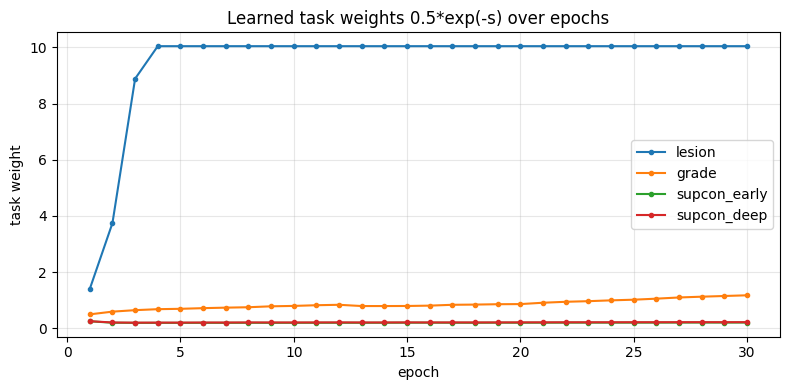

   epoch  train_loss  val_loss  grade_acc  grade_kappa  lesion_f1  lesion_auc  \
4     26    0.621407  0.967016   0.757809     0.918363   0.770736    0.959443   
5     27    0.586160  0.977043   0.758289     0.917322   0.761656    0.957692   
6     28    0.584204  0.963578   0.758289     0.919148   0.771319    0.957433   
7     29    0.579613  0.960385   0.760692     0.920980   0.774145    0.957903   
8     30    0.527744  1.037526   0.757809     0.921118   0.777879    0.958070   

   lesion_pr_auc   w_lesion   w_grade  w_supcon_early  w_supcon_deep  \
4       0.833118  10.042768  1.056555        0.204207       0.218437   
5       0.832478  10.042768  1.099018        0.205628       0.219457   
6       0.833353  10.042768  1.126929        0.206432       0.219989   
7       0.833498  10.042768  1.151574        0.205603       0.219461   
8       0.839533  10.042768  1.176377        0.205859       0.220615   

   s_lesion   s_grade  s_supcon_early  s_supcon_deep  
4      -3.0 -0.748161    

In [51]:
def plot_weight_trajectories(history, names):
    if history is None or len(history) == 0:
        # synthetic illustration: lesion loss higher -> its weight drifts below grade's
        ep = np.arange(1, 31)
        demo = {'lesion': 0.5*np.exp(-np.linspace(0, 1.2, 30)),
                'grade':  0.5*np.exp(-np.linspace(0, -0.3, 30))}
        plt.figure(figsize=(8, 4))
        for k, v in demo.items():
            plt.plot(ep, v, marker='.', label=f'{k} (illustrative)')
        plt.title('Task weights over epochs (SYNTHETIC illustration)')
    else:
        H = np.array(history)  # [epochs, n_tasks]
        plt.figure(figsize=(8, 4))
        for j, nm in enumerate(names):
            plt.plot(np.arange(1, len(H)+1), H[:, j], marker='.', label=nm)
        plt.title('Learned task weights 0.5*exp(-s) over epochs')
    plt.xlabel('epoch'); plt.ylabel('task weight'); plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_weight_trajectories(weight_history, TASK_NAMES)

# also load and preview the CSV log if it exists
if os.path.exists(CSV_LOG):
    print(pd.read_csv(CSV_LOG).tail())
else:
    print("(No training CSV yet - run with RUN_TRAINING=True to populate it.)")

## 20. Future Improvements
- **Ablations:** `UNCERTAINTY_ON_SUPCON=True` (weight all 4 tasks) vs primary (grade+lesion only);
  `INIT_LOG_VAR` sensitivity; vs **GradNorm** / **PCGrad**; vs a manual weight grid (show learned ~
  best-manual, cheaper).
- **Heteroscedastic uncertainty:** per-image noise head for hard rare-lesion mining.
- **UW-SO** (softmax-normalised analytically-optimal weights) if plain UW overfits the weights.
- **Per-lesion-class uncertainty:** 7 sigmas inside the lesion head to further protect NV/VH/RD.
- **Stratified split** on rare lesions to stabilise variance; report mean±std over >=3 seeds + a paired
  significance test vs the folder-3 fixed-weight baseline.
- **Calibration (ECE)** as a nice-to-have clinical metric.

**Baseline to beat (folder 3, UWF val):** Grade Acc 76.3%, Kappa 0.922, Lesion macro-F1 0.738, macro-AUC
0.951 — match/beat these while **raising NV/VH/RD recall**.